In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shutil
import torch.nn as nn
import os
import pandas as pd
import random

from PatchDataset import load_dataset
from torch.utils.data import DataLoader,Subset,Dataset
from torchvision import datasets, transforms
from PIL import Image
from tqdm import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, confusion_matrix
from transformers import CLIPProcessor, CLIPModel



In [ ]:
PATCH_SIZE = 224
BATCH_SIZE = 32
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PATCHES_ROOT = "patches_dataset/patches_v3_seed42"
csv_path = os.path.join(PATCHES_ROOT, "metadata.csv")


In [3]:
# loading the dataset
df = pd.read_csv(csv_path)
df["patch_id"] = df["patch_id"].astype(int)
df["label"] = df["label"].astype(int)
df["type"] = df["type"].astype(str)

train_dataset,test_dataset,train_loader,test_loader = load_dataset(df,PATCHES_ROOT,BATCH_SIZE)

for xb,yb in train_loader:
    print(xb.shape,yb.shape,min(yb),max(yb))
    break

train/test: 7056 1764
torch.Size([32, 3, 224, 224]) torch.Size([32]) tensor(0.) tensor(1.)


In [ ]:

model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor_clip = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")



Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [6]:
# some testing individual images

#imp = "patches_dataset/patches_v1_seed42/negative/817.png"
#imp = "patches_dataset/patches_v1_seed42/negative/0.png"
#imp = "patches_dataset/patches_v1_seed42/negative/49.png"
imp = "patches_dataset/patches_v1_seed42/negative/0.png"
image = Image.open(imp)
labels = [
    #"a tree",
    #"not a tree"
    "an aerial image of a patch of land without a tree",
    "an aerial image of a patch of land with a tree",
    "an aerial image of a house",
    "an areal image of a branch on the ground"
]

inputs = processor_clip(text=labels, images=image, return_tensors="pt", padding=True)

outputs = model_clip(**inputs)
logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)
most_likely_idx = probs.argmax(dim=1).item()
most_likely_label = labels[most_likely_idx]
print(f"Most likely label: {most_likely_label} with probability: {probs[0][most_likely_idx].item():.3f}")


Most likely label: an aerial image of a patch of land with a tree with probability: 0.487


In [7]:
prompt_sets = {
    "simple": ["tree", "no tree"],
    "article": [
        "an image of a tree", 
        "an image of land without trees"
    ],
    "aerial": [
        "aerial view tree patch",
        "aerial view empty land"
    ],
    "detailed": [
        "aerial forest patch with tree crown and branches", 
        "aerial forest patch with bare ground and no vegetation"
    ],
    "negative": [
        "patch with single tree",
        "patch with no trees no vegetation no branches"
    ],
    "expert": [
        "aerial orthophoto with tree canopy", 
        "aerial orthophoto barren forest floor"
    ]
}

In [21]:
def eval_clip(model, processor, loader, prompts, device, max_batches=100):
    model.eval()
    all_pos_scores = []
    all_labels = []
    
    with torch.no_grad():
        for i, (images, labels) in enumerate(tqdm(loader)):
            if i >= max_batches: break
            
            images = images.to(device)
            inputs = processor(
                text=prompts, 
                images=images,  
                return_tensors="pt", 
                padding=True
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            outputs = model(**inputs)
            logits_per_image = outputs.logits_per_image  # size (B, len(prompts))

            probs = torch.softmax(logits_per_image,dim=1)
            pos_score = probs[:,0] # the first column is for trees (second is no tree)

            all_pos_scores.extend(pos_score.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    y_score = np.array(all_pos_scores)
    y_true = np.array(all_labels)
    auroc = roc_auc_score(y_true, y_score)
    return auroc, y_score, y_true

device = "cuda" if torch.cuda.is_available() else "cpu"
model_clip = model_clip.to(device)


In [ ]:
results = {}
for name, prompts in prompt_sets.items():
    auc = eval_clip(model_clip, processor_clip, test_loader, prompts, device)
    results[name] = auc
    print(f"{name:20}: AUROC {auc:.4f}")


100%|██████████| 56/56 [03:42<00:00,  3.97s/it]


simple              : AUROC 0.5860


100%|██████████| 56/56 [03:45<00:00,  4.02s/it]


article             : AUROC 0.6359


100%|██████████| 56/56 [10:36<00:00, 11.36s/it]   


...

detailed            : AUROC 0.6127


100%|██████████| 56/56 [03:43<00:00,  3.99s/it]


negative            : AUROC 0.4892


100%|██████████| 56/56 [03:42<00:00,  3.98s/it]

expert              : AUROC 0.5678


In [ ]:
auroc, scores, labels = eval_clip(model_clip, processor_clip, test_loader, prompt_sets["article"], device)

100%|██████████| 56/56 [01:27<00:00,  1.57s/it]


In [26]:
from sklearn.metrics import auc

fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

prec, rec, _ = precision_recall_curve(labels, scores)
ap = average_precision_score(labels, scores)

preds = (scores >= 0.5).astype(int)
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       755
    Positive       0.57      1.00      0.73      1009

    accuracy                           0.57      1764
   macro avg       0.29      0.50      0.36      1764
weighted avg       0.33      0.57      0.42      1764



/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


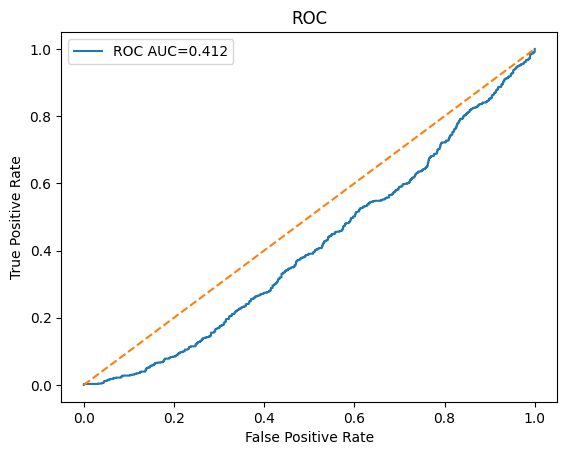

In [27]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

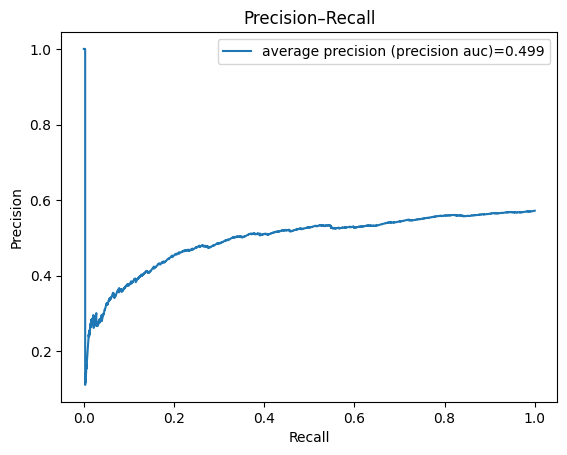

In [28]:
plt.figure()
plt.plot(rec, prec, label=f"average precision (precision auc)={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()


In [20]:
print("                            Métriques")
preds = (scores >= 0.5).astype(int)
print(np.unique(preds))
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

                            Métriques
[0]
              precision    recall  f1-score   support

    Negative       0.43      1.00      0.60       755
    Positive       0.00      0.00      0.00      1009

    accuracy                           0.43      1764
   macro avg       0.21      0.50      0.30      1764
weighted avg       0.18      0.43      0.26      1764



/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## GOPro Optimisation de prompt

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import numpy as np

class GOProPromptLearner(nn.Module):
    def __init__(self, num_classes=2, ctx_len=4):
        super().__init__()
        self.num_classes = num_classes
        
        # Learn directly in CLIP projection space (512-dim)
        dim = 512
        self.ctx = nn.Parameter(torch.randn(ctx_len, dim) * 0.02)
        self.class_token = nn.Parameter(torch.randn(num_classes, dim) * 0.02)
        self.temp = nn.Parameter(torch.ones([]) * 0.07)
    
    def forward(self, batch_size):
        # (B, ctx_len, 512) + (B, num_classes, 512)
        ctx = self.ctx.unsqueeze(0).expand(batch_size, -1, -1)
        class_toks = self.class_token.unsqueeze(0).expand(batch_size, -1, -1)
        
        # Pool context + class token
        text_feats = torch.cat([ctx.mean(1, keepdim=True), class_toks], dim=1)  # (B, 2, 512)
        return F.normalize(text_feats, dim=-1)

def train_gopro_prompts(clip_model, train_loader, num_epochs=10, lr=1e-3):
    device = next(clip_model.parameters()).device
    prompt_learner = GOProPromptLearner(num_classes=2).to(device)
    
    for p in clip_model.parameters():
        p.requires_grad_(False)
    
    optimizer = torch.optim.AdamW(prompt_learner.parameters(), lr=lr, weight_decay=0.1)
    
    prompt_learner.train()
    for epoch in range(num_epochs):
        total_loss = 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            
            # Image features
            with torch.no_grad():
                vision_outputs = clip_model.vision_model(pixel_values=images)
                pooled = vision_outputs.pooler_output
                img_feats = clip_model.visual_projection(pooled)
                img_feats = F.normalize(img_feats, dim=-1)  # (B, 512)
            
            # Text features (B, 2, 512)
            text_feats = prompt_learner(images.size(0))
            
            # Similarity logits (B, 2)
            logits = torch.einsum('bd,bcd->bc', img_feats, text_feats) * prompt_learner.temp.exp()
            labels = labels.to(device).long() 
            loss = F.cross_entropy(logits, labels)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(prompt_learner.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")
    
    return prompt_learner

def eval_gopro_prompts(clip_model, prompt_learner, test_loader, device):
    clip_model.eval()
    prompt_learner.eval()
    all_scores, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            
            vision_outputs = clip_model.vision_model(pixel_values=images)
            pooled = vision_outputs.pooler_output
            img_feats = clip_model.visual_projection(pooled)
            img_feats = F.normalize(img_feats, dim=-1)
            
            text_feats = prompt_learner(images.size(0))
            tree_scores = torch.einsum('bd,bcd->bc', img_feats, text_feats)[:, 1] * prompt_learner.temp.exp()
            
            all_scores.extend(tree_scores.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_scores), np.array(all_labels)


In [19]:
#from gopro_prompts import train_gopro_prompts,eval_gopro_prompts

model_clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
gopro_learner = train_gopro_prompts(model_clip, train_loader, num_epochs=1)
scores_gopro, labels = eval_gopro_prompts(model_clip, gopro_learner, test_loader, device)

# === Now use scores_gopro in your existing ROC/PR code ===
fpr, tpr, _ = roc_curve(labels, scores_gopro)
roc_auc_gopro = auc(fpr, tpr)
print(f"GOPro ROC AUC: {roc_auc_gopro:.4f}")

prec, rec, _ = precision_recall_curve(labels, scores_gopro)
ap_gopro = average_precision_score(labels, scores_gopro)
print(f"GOPro AP: {ap_gopro:.4f}")


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Epoch 1: 100%|██████████| 221/221 [08:44<00:00,  2.37s/it]


Epoch 1, Loss: 0.7725


Evaluating: 100%|██████████| 56/56 [02:07<00:00,  2.27s/it]

GOPro ROC AUC: 0.5801
GOPro AP: 0.6569


In [20]:
preds_gopro = (scores_gopro >= 0.5).astype(int)
print(classification_report(labels, preds_gopro, target_names=["Negative", "Positive"]))


              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       755
    Positive       0.57      1.00      0.73      1009

    accuracy                           0.57      1764
   macro avg       0.29      0.50      0.36      1764
weighted avg       0.33      0.57      0.42      1764



/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alant/myglobal/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


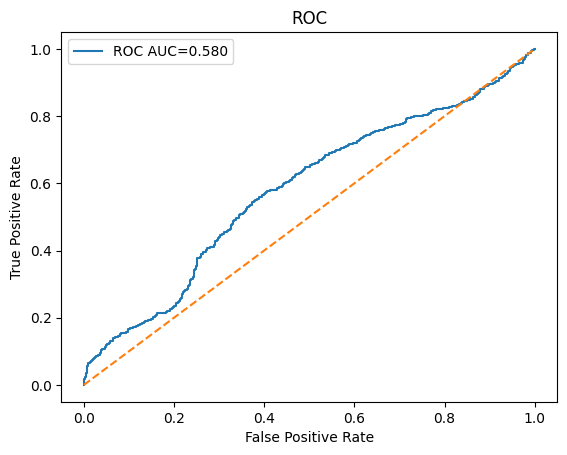

In [22]:
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc_gopro:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC")
plt.legend()
plt.show()

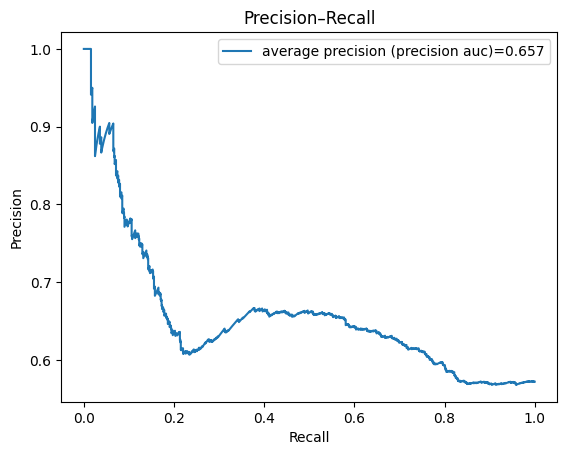

In [24]:
plt.figure()
plt.plot(rec, prec, label=f"average precision (precision auc)={ap_gopro:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall")
plt.legend()
plt.show()
